# Relaxation Spectrum Recovery: From Moduli to H(τ)

The **continuous relaxation spectrum** H(τ) is a fundamental descriptor of viscoelastic materials. It encodes the distribution of relaxation times and underpins the measured dynamic moduli through the integral relations:

$$G'(\omega) = G_e + \int_{-\infty}^{\infty} H(\tau) \frac{\omega^2 \tau^2}{1 + \omega^2 \tau^2} \, d(\ln \tau)$$

$$G''(\omega) = \int_{-\infty}^{\infty} H(\tau) \frac{\omega \tau}{1 + \omega^2 \tau^2} \, d(\ln \tau)$$

For relaxation data:

$$G(t) = G_e + \int_{-\infty}^{\infty} H(\tau) \exp(-t/\tau) \, d(\ln \tau)$$

Recovering H(τ) from measured moduli is an **ill-posed inverse problem**: small noise in the data can produce large, unphysical oscillations in H(τ). Regularization is essential.

## Learning Objectives

By the end of this notebook (~30–40 min) you will be able to:

1. Understand why spectrum inversion is ill-posed and why regularization is required
2. Apply Tikhonov regularization with automatic GCV λ selection
3. Apply the Maximum Entropy method and compare with Tikhonov
4. Diagnose under- and over-regularization through a λ sweep
5. Recover H(τ) from relaxation modulus G(t) data

In [1]:
# Google Colab Setup - Run this cell first!
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q rheojax
    import os
    os.environ['JAX_ENABLE_X64'] = 'true'
    print("✓ RheoJAX installed successfully!")

## Setup and Imports

In [2]:
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from rheojax.core.data import RheoData
from rheojax.core.jax_config import safe_import_jax, verify_float64
from rheojax.transforms.spectrum_inversion import SpectrumInversion

jax, jnp = safe_import_jax()
verify_float64()
print(f"✓ JAX float64 precision enabled")

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore', message='.*non-interactive.*')

✓ JAX float64 precision enabled


## Theory: Ill-Posed Inversion and Regularization

### Why is spectrum inversion ill-posed?

The integral equations above define a **Fredholm equation of the first kind**:

$$\mathbf{b} = A \mathbf{H}$$

where A is the kernel matrix. The singular values of A decay rapidly to zero, meaning the inverse problem is severely ill-conditioned. Even 1–2% noise in the measured moduli can produce H(τ) solutions that oscillate by orders of magnitude.

### Tikhonov Regularization

Tikhonov regularization replaces the exact inversion with a regularized minimization:

$$\min_{H \geq 0} \|A H - b\|^2 + \lambda^2 \|L H\|^2$$

where L is a penalty operator (identity for zeroth-order) and λ controls the trade-off between data fidelity and smoothness. The solution is:

$$H_\lambda = (A^T A + \lambda^2 L^T L)^{-1} A^T b$$

**Automatic λ selection via GCV:** Generalized Cross-Validation selects λ by minimizing

$$\text{GCV}(\lambda) = \frac{\|A H_\lambda - b\|^2}{\left(\text{tr}(I - A(A^T A + \lambda^2 L^T L)^{-1} A^T)\right)^2}$$

RheoJAX uses an efficient SVD-based evaluation when L = I.

### Maximum Entropy Method

The MaxEnt method maximizes the entropy of the spectrum:

$$S = -\sum_i H_i \ln(H_i / m_i)$$

subject to data fidelity, where m is a uniform prior model. MaxEnt naturally enforces non-negativity and tends to produce smoother, more compact spectra — particularly useful for materials with well-separated modes.

### Physical Interpretation

Peaks in H(τ) correspond to dominant relaxation processes. A polymer melt will show a broad, continuous distribution; a crosslinked gel shows a plateau. Discrete Maxwell modes appear as narrow peaks at their characteristic relaxation times.

## Generate Synthetic Oscillation Data

We construct G*(ω) analytically from a known 3-mode Maxwell model, then add 2% noise. This gives us a ground truth against which to evaluate the recovered spectrum.

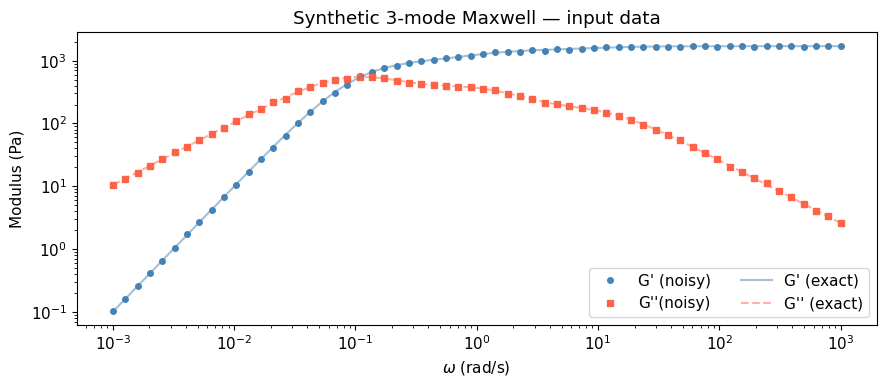

True modes: τ = [10.   1.   0.1], G = [1000.  500.  200.]


In [3]:
# True Maxwell modes: [G1, G2, G3], [tau1, tau2, tau3]
G_modes_true = np.array([1000.0, 500.0, 200.0])
tau_modes_true = np.array([10.0, 1.0, 0.1])
G_e_true = 0.0

# Frequency sweep: 60 points over 6 decades
omega = np.logspace(-3, 3, 60)

# Analytical G' and G''
G_prime = G_e_true + np.sum(
    G_modes_true * (omega[:, None] * tau_modes_true) ** 2
    / (1 + (omega[:, None] * tau_modes_true) ** 2),
    axis=1,
)
G_dprime = np.sum(
    G_modes_true * omega[:, None] * tau_modes_true
    / (1 + (omega[:, None] * tau_modes_true) ** 2),
    axis=1,
)

# Add 2% multiplicative noise
G_prime_noisy = G_prime * (1 + 0.02 * np.random.randn(len(omega)))
G_dprime_noisy = G_dprime * (1 + 0.02 * np.random.randn(len(omega)))
G_star = G_prime_noisy + 1j * G_dprime_noisy

# Wrap in RheoData
data_osc = RheoData(x=omega, y=G_star, metadata={'test_mode': 'oscillation'})

# Quick visual check
fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(omega, G_prime_noisy, 'o', ms=4, label="G' (noisy)", color='steelblue')
ax.loglog(omega, G_dprime_noisy, 's', ms=4, label='G\'\'(noisy)', color='tomato')
ax.loglog(omega, G_prime, '-', lw=1.5, label="G' (exact)", color='steelblue', alpha=0.5)
ax.loglog(omega, G_dprime, '--', lw=1.5, label="G'' (exact)", color='tomato', alpha=0.5)
ax.set_xlabel(r'$\omega$ (rad/s)')
ax.set_ylabel('Modulus (Pa)')
ax.set_title('Synthetic 3-mode Maxwell — input data')
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

print(f"True modes: τ = {tau_modes_true}, G = {G_modes_true}")

## Tikhonov Regularization

We apply `SpectrumInversion` with `method="tikhonov"`. The regularization parameter λ is automatically selected by GCV — no manual tuning needed.

In [4]:
spectrum_tik = SpectrumInversion(
    method="tikhonov",
    n_tau=100,
    source="oscillation",
)
result_tik, meta_tik = spectrum_tik.transform(data_osc)
spec_result_tik = meta_tik["spectrum_result"]

print(f"Method              : {spec_result_tik.method}")
print(f"Regularization λ    : {spec_result_tik.regularization_param:.4e}")
print(f"Residual norm       : {spec_result_tik.residual_norm:.4f}")
print(f"τ range             : [{spec_result_tik.tau.min():.3e}, {spec_result_tik.tau.max():.3e}] s")
print(f"H(τ) max            : {spec_result_tik.H_tau.max():.2f} Pa")

Method              : tikhonov
Regularization λ    : 7.5431e-03
Residual norm       : 7617.8501
τ range             : [1.000e-04, 1.000e+04] s
H(τ) max            : 1228.67 Pa


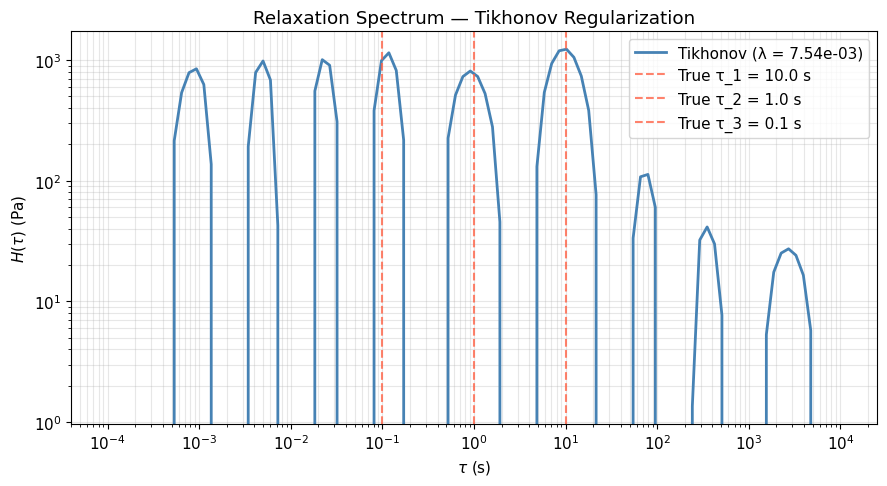


Peaks in H(τ) should align with the vertical dashed lines at τ = 0.1, 1, 10 s.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.loglog(
    spec_result_tik.tau,
    spec_result_tik.H_tau,
    '-',
    lw=2,
    color='steelblue',
    label=f'Tikhonov (λ = {spec_result_tik.regularization_param:.2e})',
)

# Overlay true mode positions as vertical lines
for i, (tau_i, G_i) in enumerate(zip(tau_modes_true, G_modes_true)):
    ax.axvline(
        tau_i,
        color='tomato',
        linestyle='--',
        lw=1.5,
        alpha=0.8,
        label=f'True τ_{i+1} = {tau_i} s' if i == 0 else f'True τ_{i+1} = {tau_i} s',
    )

ax.set_xlabel(r'$\tau$ (s)')
ax.set_ylabel(r'$H(\tau)$ (Pa)')
ax.set_title('Relaxation Spectrum — Tikhonov Regularization')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPeaks in H(τ) should align with the vertical dashed lines at τ = 0.1, 1, 10 s.")

## Maximum Entropy Method

The MaxEnt method maximizes the entropy of H(τ) subject to data fidelity. It naturally enforces non-negativity through a multiplicative update scheme and tends to produce compact, smooth spectra.

In [6]:
spectrum_me = SpectrumInversion(
    method="max_entropy",
    n_tau=100,
    source="oscillation",
)
result_me, meta_me = spectrum_me.transform(data_osc)
spec_result_me = meta_me["spectrum_result"]

print(f"Method              : {spec_result_me.method}")
print(f"Regularization λ    : {spec_result_me.regularization_param:.4e}")
print(f"Residual norm       : {spec_result_me.residual_norm:.4f}")
print(f"H(τ) max            : {spec_result_me.H_tau.max():.2f} Pa")

Method              : max_entropy
Regularization λ    : 1.0000e+00
Residual norm       : 4205.6023
H(τ) max            : 319.17 Pa


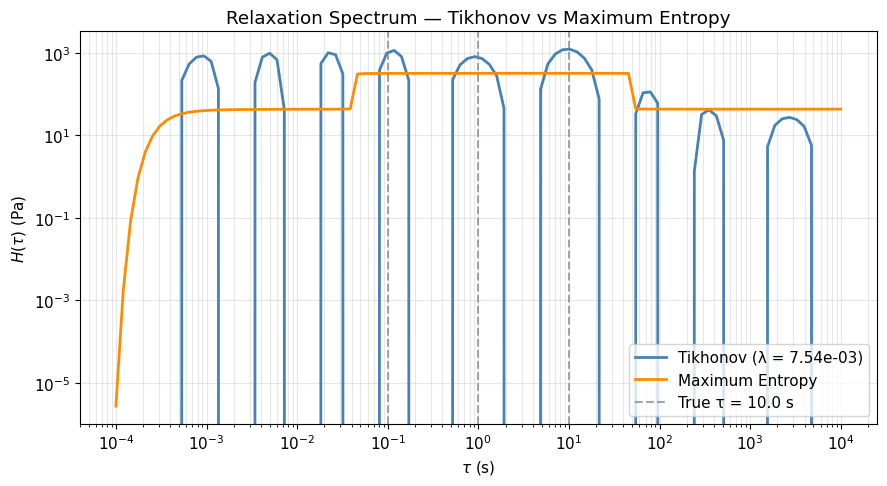

Tikhonov and MaxEnt often agree on peak locations but differ in peak shape.
MaxEnt tends toward broader, smoother distributions.


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.loglog(
    spec_result_tik.tau,
    spec_result_tik.H_tau,
    '-',
    lw=2,
    color='steelblue',
    label=f'Tikhonov (λ = {spec_result_tik.regularization_param:.2e})',
)
ax.loglog(
    spec_result_me.tau,
    spec_result_me.H_tau,
    '-',
    lw=2,
    color='darkorange',
    label='Maximum Entropy',
)

for i, tau_i in enumerate(tau_modes_true):
    ax.axvline(
        tau_i,
        color='gray',
        linestyle='--',
        lw=1.5,
        alpha=0.7,
        label=f'True τ = {tau_i} s' if i == 0 else '_nolegend_',
    )

ax.set_xlabel(r'$\tau$ (s)')
ax.set_ylabel(r'$H(\tau)$ (Pa)')
ax.set_title('Relaxation Spectrum — Tikhonov vs Maximum Entropy')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print("Tikhonov and MaxEnt often agree on peak locations but differ in peak shape.")
print("MaxEnt tends toward broader, smoother distributions.")

## Effect of Regularization Strength

To build intuition, we manually sweep λ across several decades and observe the transition from **under-regularization** (noisy, oscillatory spectrum) to **over-regularization** (over-smoothed, smeared peaks).

The GCV-selected λ from the automatic method should sit in the optimal zone.

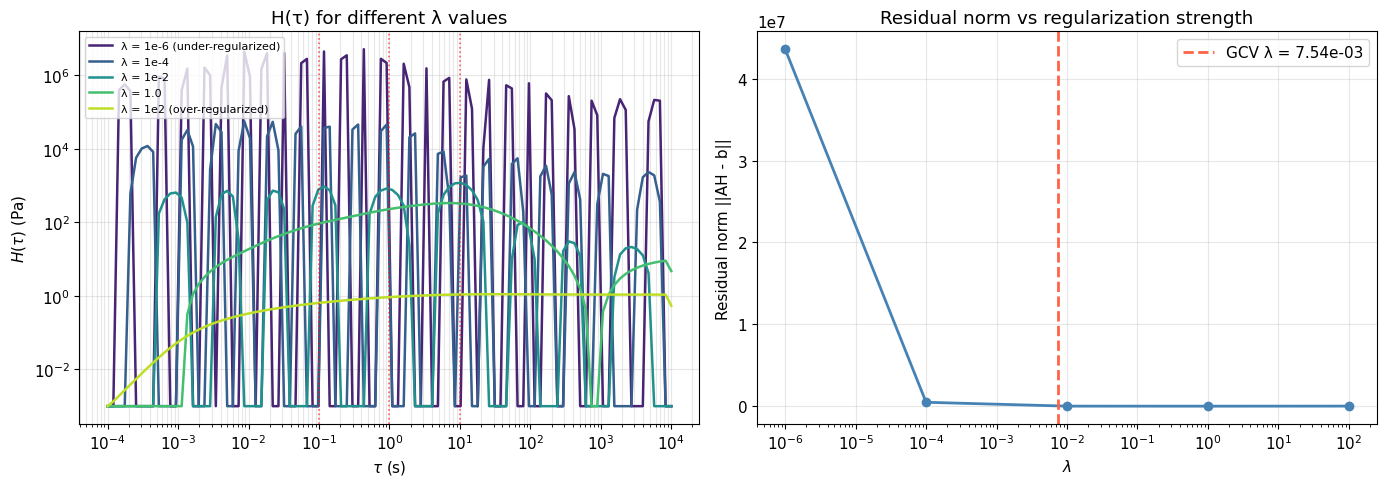

Left: Small λ → noisy spectrum. Large λ → smeared, featureless spectrum.
Right: The residual norm increases monotonically with λ — GCV balances this trade-off.


In [8]:
lambda_values = [1e-6, 1e-4, 1e-2, 1e0, 1e2]
labels = [
    'λ = 1e-6 (under-regularized)',
    'λ = 1e-4',
    'λ = 1e-2',
    'λ = 1.0',
    'λ = 1e2 (over-regularized)',
]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(lambda_values)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax_spec = axes[0]
ax_res = axes[1]

res_norms = []

for lam, label, color in zip(lambda_values, labels, colors):
    inv = SpectrumInversion(
        method="tikhonov",
        n_tau=100,
        source="oscillation",
        regularization=lam,
    )
    _, meta = inv.transform(data_osc)
    sr = meta["spectrum_result"]
    res_norms.append(sr.residual_norm)

    # Clip very small values for log plot
    H_plot = np.maximum(sr.H_tau, 1e-3)
    ax_spec.loglog(sr.tau, H_plot, '-', lw=1.8, color=color, label=label)

# Mark true mode positions
for tau_i in tau_modes_true:
    ax_spec.axvline(tau_i, color='red', linestyle=':', lw=1.2, alpha=0.6)

# Mark GCV-selected lambda on residual plot
ax_res.semilogx(lambda_values, res_norms, 'o-', color='steelblue', lw=2)
ax_res.axvline(
    spec_result_tik.regularization_param,
    color='tomato',
    linestyle='--',
    lw=2,
    label=f'GCV λ = {spec_result_tik.regularization_param:.2e}',
)

ax_spec.set_xlabel(r'$\tau$ (s)')
ax_spec.set_ylabel(r'$H(\tau)$ (Pa)')
ax_spec.set_title('H(τ) for different λ values')
ax_spec.legend(fontsize=8, loc='upper left')
ax_spec.grid(True, which='both', alpha=0.3)

ax_res.set_xlabel(r'$\lambda$')
ax_res.set_ylabel('Residual norm ||AH - b||')
ax_res.set_title('Residual norm vs regularization strength')
ax_res.legend()
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: Small λ → noisy spectrum. Large λ → smeared, featureless spectrum.")
print("Right: The residual norm increases monotonically with λ — GCV balances this trade-off.")

## Spectrum from Relaxation Data

The same transform works on time-domain relaxation modulus G(t) data by setting `source="relaxation"`. The kernel changes from the oscillatory Fredholm kernel to an exponential (Laplace-type) kernel:

$$G(t) = G_e + \int H(\tau) \exp(-t/\tau) \, d(\ln \tau)$$

Relaxation source — Method : tikhonov
Regularization λ           : 1.9307e-02
Residual norm              : 1370.7195


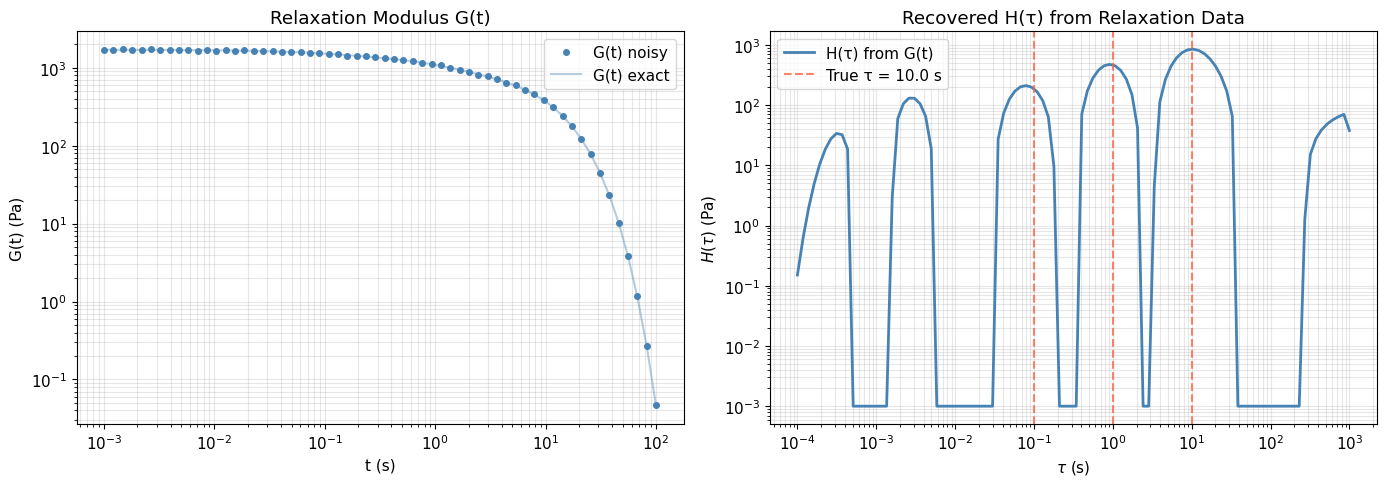

In [9]:
# Generate synthetic G(t) from the same 3-mode Maxwell model
t_relax = np.logspace(-3, 2, 60)

G_relax_exact = G_e_true + np.sum(
    G_modes_true * np.exp(-t_relax[:, None] / tau_modes_true),
    axis=1,
)

# Add 1% noise
G_relax_noisy = G_relax_exact * (1 + 0.01 * np.random.randn(len(t_relax)))

data_relax = RheoData(x=t_relax, y=G_relax_noisy, metadata={'test_mode': 'relaxation'})

# Apply spectrum inversion with source='relaxation'
spectrum_relax = SpectrumInversion(
    method="tikhonov",
    n_tau=100,
    source="relaxation",
)
result_relax, meta_relax = spectrum_relax.transform(data_relax)
spec_relax = meta_relax["spectrum_result"]

print(f"Relaxation source — Method : {spec_relax.method}")
print(f"Regularization λ           : {spec_relax.regularization_param:.4e}")
print(f"Residual norm              : {spec_relax.residual_norm:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: input data
axes[0].loglog(t_relax, G_relax_noisy, 'o', ms=4, color='steelblue', label='G(t) noisy')
axes[0].loglog(t_relax, G_relax_exact, '-', lw=1.5, color='steelblue', alpha=0.4, label='G(t) exact')
axes[0].set_xlabel('t (s)')
axes[0].set_ylabel('G(t) (Pa)')
axes[0].set_title('Relaxation Modulus G(t)')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Right: recovered spectrum
H_relax_plot = np.maximum(spec_relax.H_tau, 1e-3)
axes[1].loglog(spec_relax.tau, H_relax_plot, '-', lw=2, color='steelblue', label='H(τ) from G(t)')
for i, tau_i in enumerate(tau_modes_true):
    axes[1].axvline(
        tau_i,
        color='tomato',
        linestyle='--',
        lw=1.5,
        alpha=0.8,
        label=f'True τ = {tau_i} s' if i == 0 else '_nolegend_',
    )
axes[1].set_xlabel(r'$\tau$ (s)')
axes[1].set_ylabel(r'$H(\tau)$ (Pa)')
axes[1].set_title('Recovered H(τ) from Relaxation Data')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## Key Takeaways

1. **Spectrum inversion is ill-posed.** Small noise in G'(ω) or G''(ω) amplifies into large oscillations in H(τ) without regularization.

2. **Tikhonov regularization (default) is robust.** Automatic GCV λ selection removes the need for manual tuning in most cases. Use `regularization=None` (the default) to enable GCV.

3. **MaxEnt produces smoother, non-negative spectra.** It is better suited when the spectrum is expected to be compact or when strong prior knowledge of positivity exists.

4. **Peaks in H(τ) correspond to dominant relaxation processes.** For a 3-mode Maxwell model, three distinct peaks appear at τ = 0.1, 1, and 10 s — consistent with the true relaxation times.

5. **Regularization strength matters.** Too little λ → noisy, oscillatory spectrum. Too much λ → smeared, featureless spectrum. GCV finds the balance automatically.

6. **The same API works for G(t) data.** Set `source="relaxation"` to switch from the oscillatory Fredholm kernel to the exponential relaxation kernel.

### API Quick Reference

```python
from rheojax.transforms.spectrum_inversion import SpectrumInversion

# Automatic GCV regularization (recommended)
spectrum = SpectrumInversion(method="tikhonov", n_tau=100, source="oscillation")
result_data, meta = spectrum._transform(data)
spec = meta["spectrum_result"]  # SpectrumResult: .tau, .H_tau, .regularization_param

# Manual regularization
spectrum = SpectrumInversion(method="tikhonov", regularization=1e-3, source="oscillation")

# MaxEnt
spectrum = SpectrumInversion(method="max_entropy", source="oscillation")

# From relaxation data
spectrum = SpectrumInversion(method="tikhonov", source="relaxation")
```

## Session Information

In [10]:
import platform
import rheojax

print(f"Python          : {platform.python_version()}")
print(f"Platform        : {platform.platform()}")
print(f"RheoJAX version : {rheojax.__version__}")
print(f"JAX version     : {jax.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"JAX backend     : {jax.default_backend()}")

Python          : 3.13.7
Platform        : Linux-6.8.0-124-generic-x86_64-with-glibc2.39
RheoJAX version : 0.6.1
JAX version     : 0.10.1
NumPy version   : 2.4.6
JAX backend     : gpu
